# Lab 4: Regression and Classification Evaluation Metrics
## Part 1: Comprehensive Study of K-Nearest Neighbours (KNN) Classification using Breast Cancer Dataset

**Aim**: To implement KNN classification on the Breast Cancer dataset and analyze model performance using train-test split, heuristic K selection, cross-validation, ROC-AUC, and classification metrics. Also, to compare classification metrics with regression metrics studied in Linear Regression (Lab 3).

## Task 1: Data Preparation
Load the dataset from the CSV file, map the target classes, check for missing values/duplicates, and apply feature scaling.

**Why is Feature Scaling important for KNN?**
Distance-based algorithms like KNN are sensitive to feature scales. Standardizing ensures no single feature dominates the distance computation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from matplotlib.colors import ListedColormap
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('data/brca.csv')

# Handle unnamed index column if it exists
if df.columns[0] == 'Unnamed: 0' or df.columns[0] == '':
    df = df.iloc[:, 1:]

# Display structure
display(df.head())
print(f"Dataset shape: {df.shape}")

# Check missing values and duplicates
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# Map target: M=0 (Malignant), B=1 (Benign)
df['y'] = df['y'].map({'M': 0, 'B': 1})

# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,0.05766,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,0.06811,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,0.06905,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,0.05863,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,0.06503,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


Dataset shape: (569, 31)
Missing values: 0
Duplicates: 0


## Task 2: Train-Test Split Analysis
Compare performance across 80:20, 70:30, and 90:10 splits.

**Analysis of Dataset Splitting:**
Accuracy varies because the training subset changes. A 90:10 split yields higher evaluation variance, while 80:20 or 70:30 balances stability and generalization.

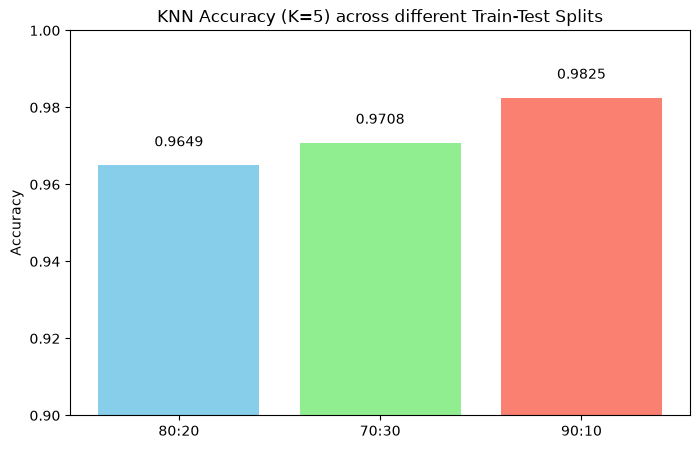

In [2]:
splits = [(0.2, '80:20'), (0.3, '70:30'), (0.1, '90:10')]
results = {}

for test_size, name in splits:
    # Using stratify=y to ensure class balance across splits
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42, stratify=y)
    
    # Train a basic KNN (k=5)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)

# Plotting the results
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['skyblue', 'lightgreen', 'salmon'])
plt.ylabel('Accuracy')
plt.title('KNN Accuracy (K=5) across different Train-Test Splits')
plt.ylim(0.9, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center')
plt.show()


## Task 3: KNN Model with Heuristic K Selection

### 3.1 Heuristic Method for K Selection
A common rule of thumb is $K = \sqrt{n}$ where n is the number of training samples.

In [3]:
# Using 80:20 split as default
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

n_train = len(X_train)
heuristic_k = int(np.sqrt(n_train))
if heuristic_k % 2 == 0:
    heuristic_k -= 1 # Ensure K is odd to avoid ties

print(f"Number of training samples (n): {n_train}")
print(f"Heuristic initial K (approx sqrt(n)): {heuristic_k}")


Number of training samples (n): 455
Heuristic initial K (approx sqrt(n)): 21


### 3.2 Model Training
Evaluating accuracy across different values of K around the heuristic K.

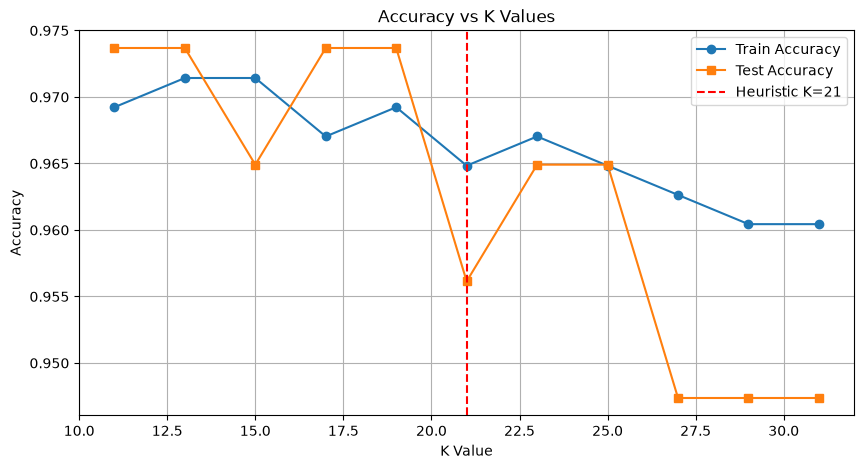

Optimal K based on Test Accuracy: 11


In [4]:
k_values = range(max(1, heuristic_k - 10), heuristic_k + 11, 2)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(k_values, test_accuracies, label='Test Accuracy', marker='s')
plt.axvline(x=heuristic_k, color='r', linestyle='--', label=f'Heuristic K={heuristic_k}')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Values')
plt.legend()
plt.grid(True)
plt.show()

optimal_k_split = k_values[np.argmax(test_accuracies)]
print(f"Optimal K based on Test Accuracy: {optimal_k_split}")


### 3.3 Distance Matrix and Decision Boundary Mapping

**Distance Metrics:**
1. **Euclidean**: Straight-line distance, best for scaled continuous data.
2. **Manhattan**: Grid-based distance, suited for discrete or high-dimensional data.

**Decision Boundary Analysis:**
Small K (e.g., K=1) creates complex, overfitted boundaries that capture noise. Large K creates smoother boundaries but risks underfitting.

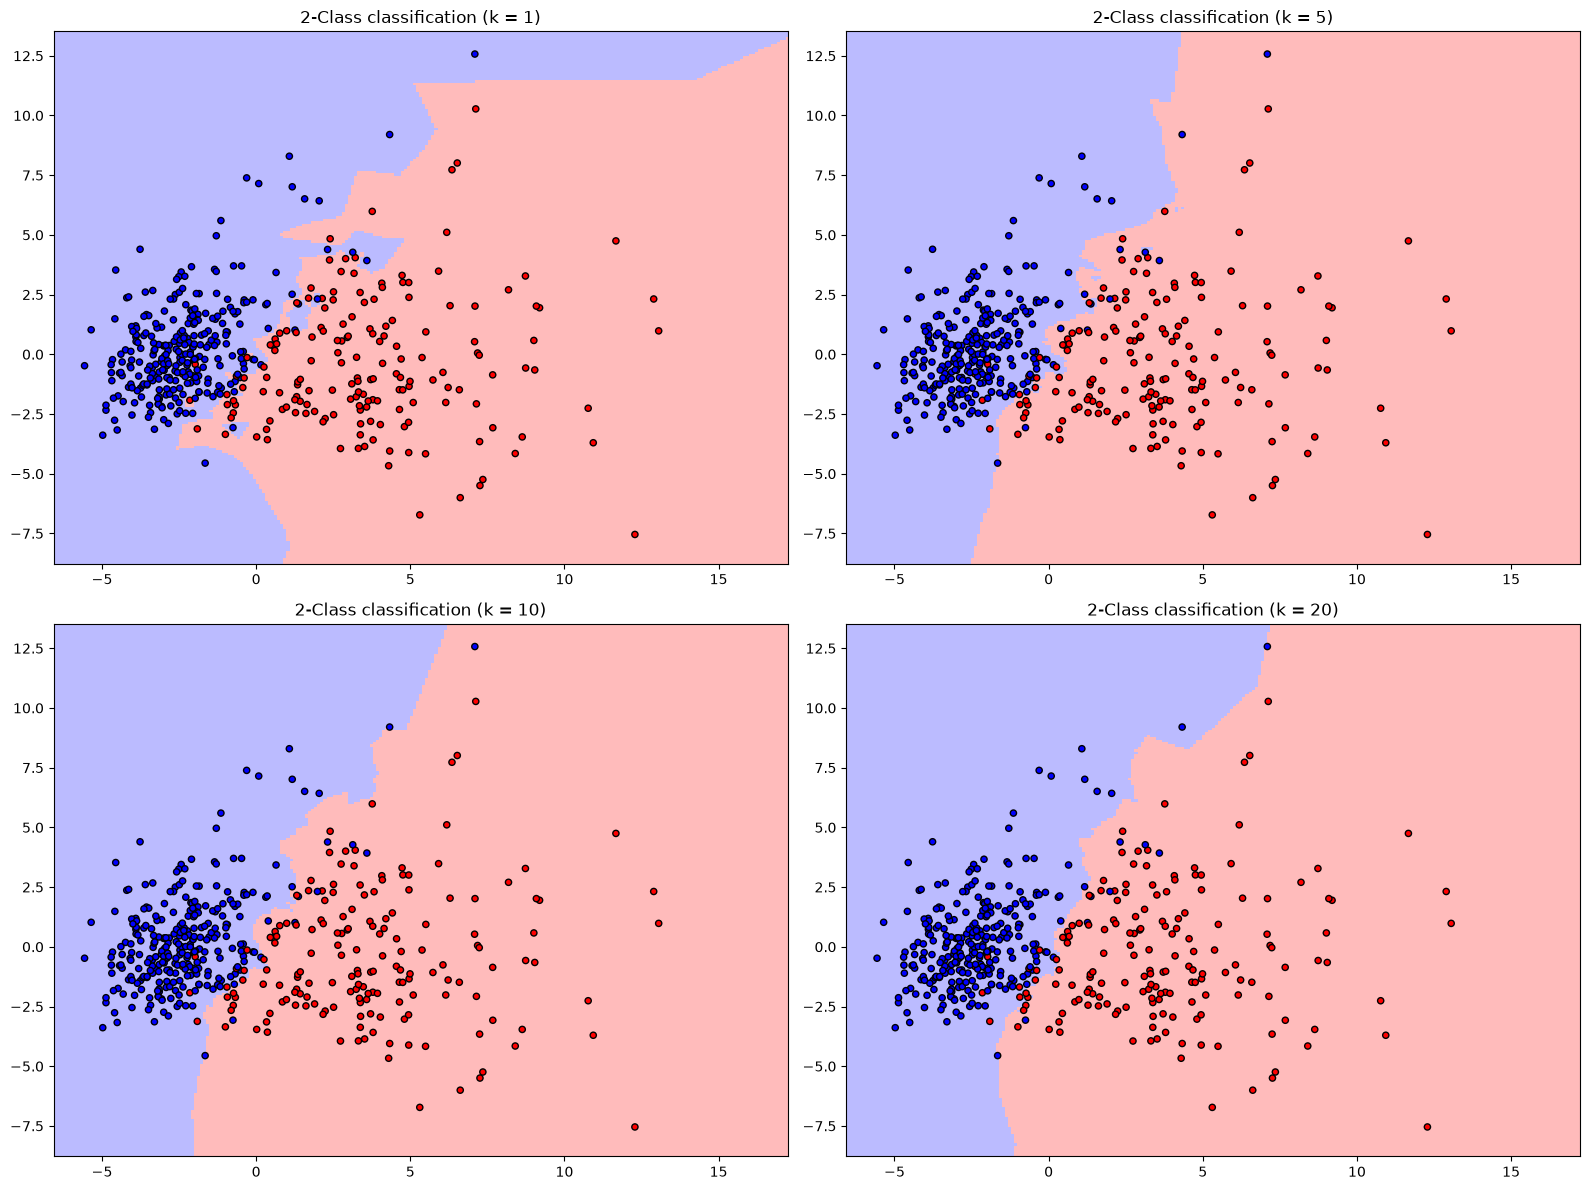

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42, stratify=y)

k_list = [1, 5, 10, 20]
plt.figure(figsize=(16, 12))
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

for i, k in enumerate(k_list, 1):
    knn_pca = KNeighborsClassifier(n_neighbors=k)
    knn_pca.fit(X_train_pca, y_train_pca)
    
    x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
    y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    
    Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.subplot(2, 2, i)
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train_pca, cmap=cmap_bold, edgecolor='k', s=20)
    plt.title(f"2-Class classification (k = {k})")
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

plt.tight_layout()
plt.show()


## Task 4: Cross Validation
Applying 5-Fold Cross Validation to ensure robustness and find the globally optimal K over the entire scaled dataset.

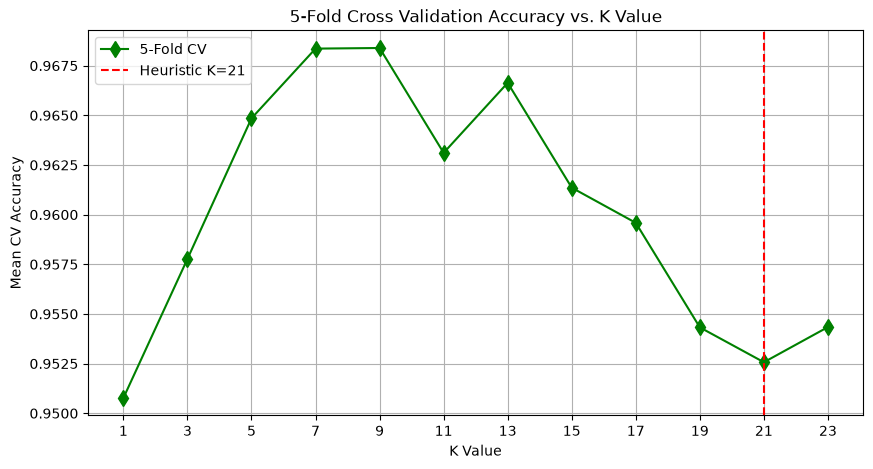

Best K based on Cross-Validation: 9


In [6]:
k_folds = 5
cv_scores = []
k_range = range(1, 25, 2)

for k in k_range:
    knn_cv = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn_cv, X_scaled, y, cv=k_folds, scoring='accuracy')
    cv_scores.append(scores.mean())

plt.figure(figsize=(10, 5))
plt.plot(k_range, cv_scores, marker='d', linestyle='-', color='g', markersize=8, label='5-Fold CV')
plt.axvline(x=heuristic_k, color='r', linestyle='--', label=f'Heuristic K={heuristic_k}')
plt.title(f'{k_folds}-Fold Cross Validation Accuracy vs. K Value')
plt.xlabel('K Value')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_range)
plt.legend()
plt.grid(True)
plt.show()

best_k_cv = k_range[np.argmax(cv_scores)]
print(f"Best K based on Cross-Validation: {best_k_cv}")


## Task 5: Classification Evaluation
Using the best K to evaluate the model through Confusion Matrix, Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Accuracy: 0.9737
Precision (Malignant): 1.0000
Recall (Malignant): 0.9286
F1 Score (Malignant): 0.9630



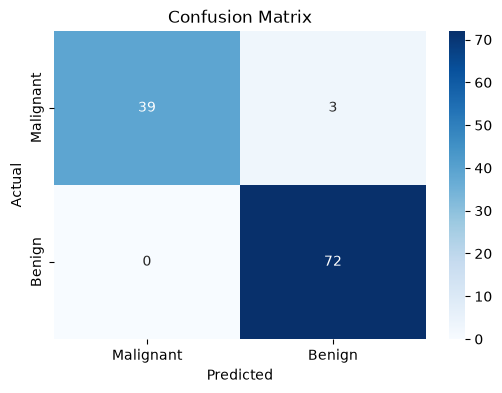

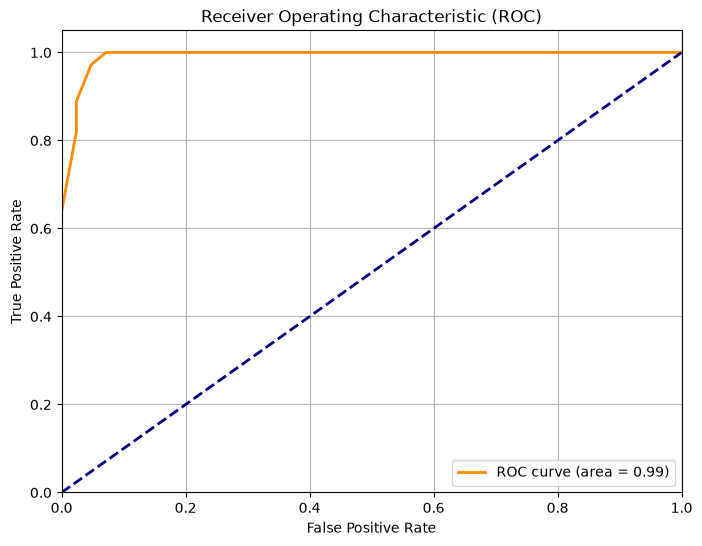

In [7]:
# Using the best K from CV
final_knn = KNeighborsClassifier(n_neighbors=best_k_cv)
final_knn.fit(X_train, y_train)
y_pred_final = final_knn.predict(X_test)
y_prob = final_knn.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred_final)
prec = precision_score(y_test, y_pred_final, pos_label=0) # 0 is Malignant
rec = recall_score(y_test, y_pred_final, pos_label=0)
f1 = f1_score(y_test, y_pred_final, pos_label=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision (Malignant): {prec:.4f}")
print(f"Recall (Malignant): {rec:.4f}")
print(f"F1 Score (Malignant): {f1:.4f}\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## Task 6: Comparative Study with Regression (Lab 3 Integration)

### Inference:
- **Regression**: Measures physical error magnitude of predictions.
- **Classification**: Evaluates logical correctness of categorical decisions.
- **Accuracy flaw**: Highly misleading when datasets are severely imbalanced.
- **Healthcare priority**: Recall minimizes fatal false negatives over raw accuracy.

## Task 7: Analytical Questions

1. **Why is KNN called a lazy learning algorithm?**
It delays all computation until prediction by simply storing the training data.

2. **Why is feature scaling required in KNN?**
Prevents variables with large numeric ranges from dominating the distance metrics.

3. **Explain heuristic K selection using $\sqrt{n}$ rule.**
A balanced rule of thumb allowing $K$ to scale safely with dataset size without overfitting.

4. **Why is cross-validation more reliable than a single train-test split?**
It tests the model across multiple data subsets, ensuring performance isn't just from a "lucky" split.

5. **How does K affect bias-variance trade-off?**
Small K = low bias, high variance (overfitting). Large K = high bias, low variance (underfitting).

6. **Why is recall more important than accuracy in cancer prediction?**
It specifically minimizes False Negatives (missing a cancer diagnosis), which is critical.

7. **What is the limitation of very large K values?**
The model becomes too rigid and simply predicts the majority class, ignoring local data structures.

## Conclusion

We applied KNN to classify Breast Cancer. Heuristic $\sqrt{n}$ provided a solid baseline, but K-Fold CV identified the optimal K. We observed that train-test splits cause variance, emphasizing CV's robustness. For medical data, Recall and ROC-AUC proved more critical than Accuracy. Finally, classification metrics focus on categorical correctness, unlike regression which measures error magnitude.